In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/raw/index_1.csv")
df.head(10)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,33.8,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk


In [5]:
df['coffee_name'].unique()

array(['Latte', 'Hot Chocolate', 'Americano', 'Americano with Milk',
       'Cocoa', 'Cortado', 'Espresso', 'Cappuccino'], dtype=object)

In [6]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [7]:
hourly_coffee_sales = df.groupby(df['datetime'].dt.hour)['money'].sum()

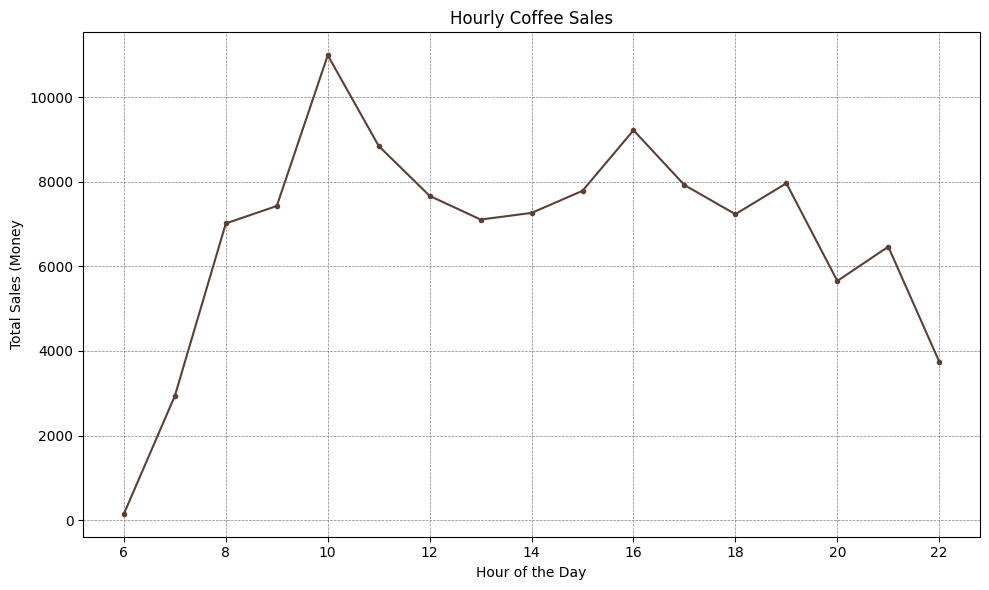

In [8]:
plt.figure(figsize=(10, 6))
hourly_coffee_sales.plot(kind='line', marker='.', linestyle='-', color="#5C4033")
plt.title('Hourly Coffee Sales')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Sales (Money')
plt.grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()

In [10]:
df['hour'] = df['datetime'].dt.hour

In [11]:
df["hourly_total_sales"] = df.groupby(["hour", "coffee_name"])["money"].transform("sum")

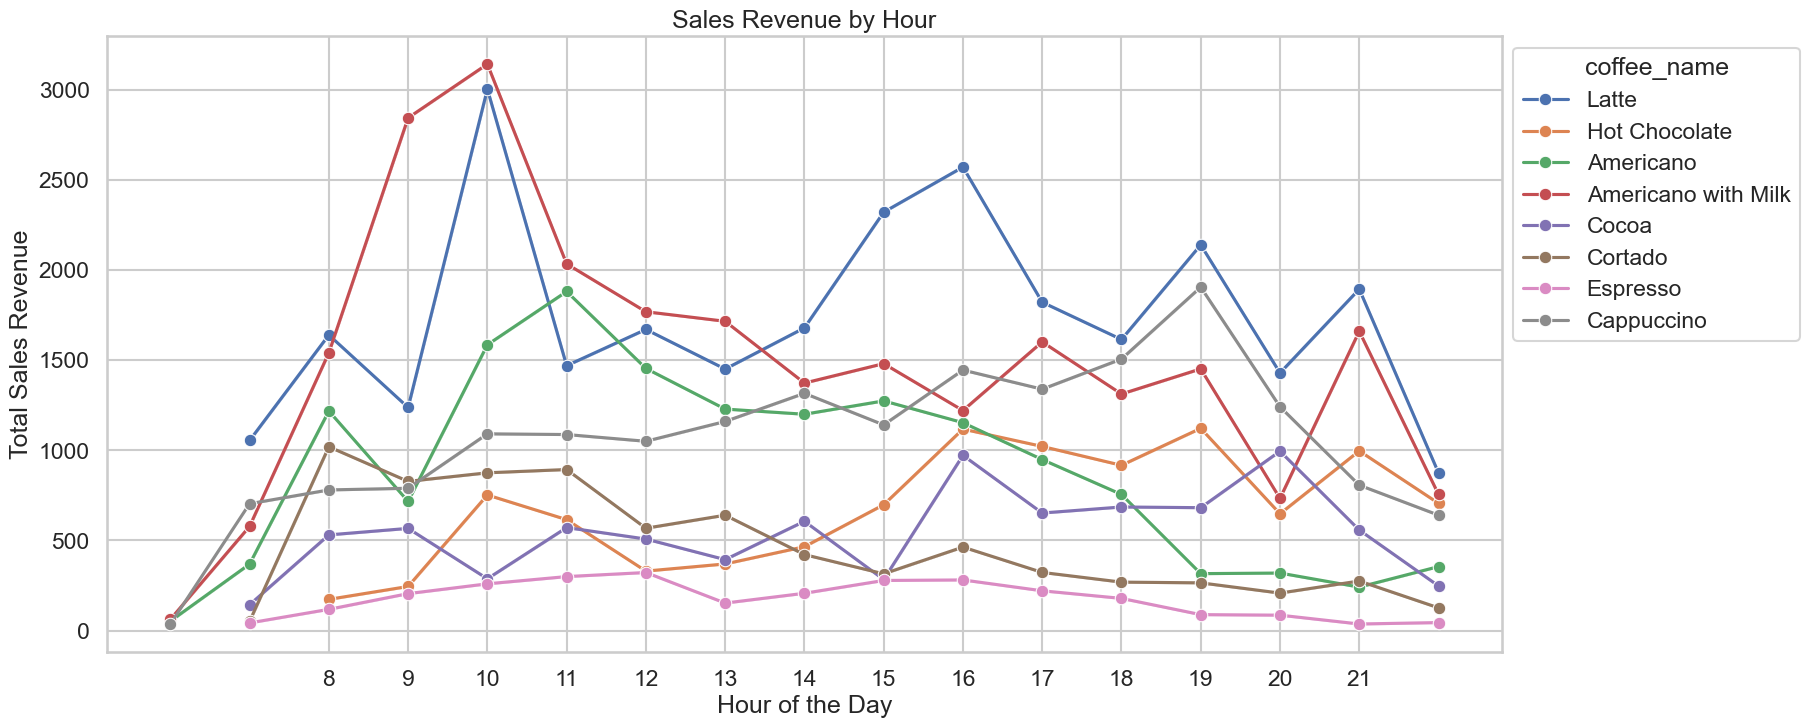

In [12]:
plt.figure(figsize=(18, 8))

sns.set(style="whitegrid")
sns.set_context("talk")

ax = sns.lineplot(data=df, x="hour", y="hourly_total_sales", hue="coffee_name", marker="o")

plt.title("Sales Revenue by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Total Sales Revenue")
plt.xticks(range(8, 22))

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.show()

In [13]:
daily_sales = df.groupby(df['datetime'].dt.date )['money'].sum()

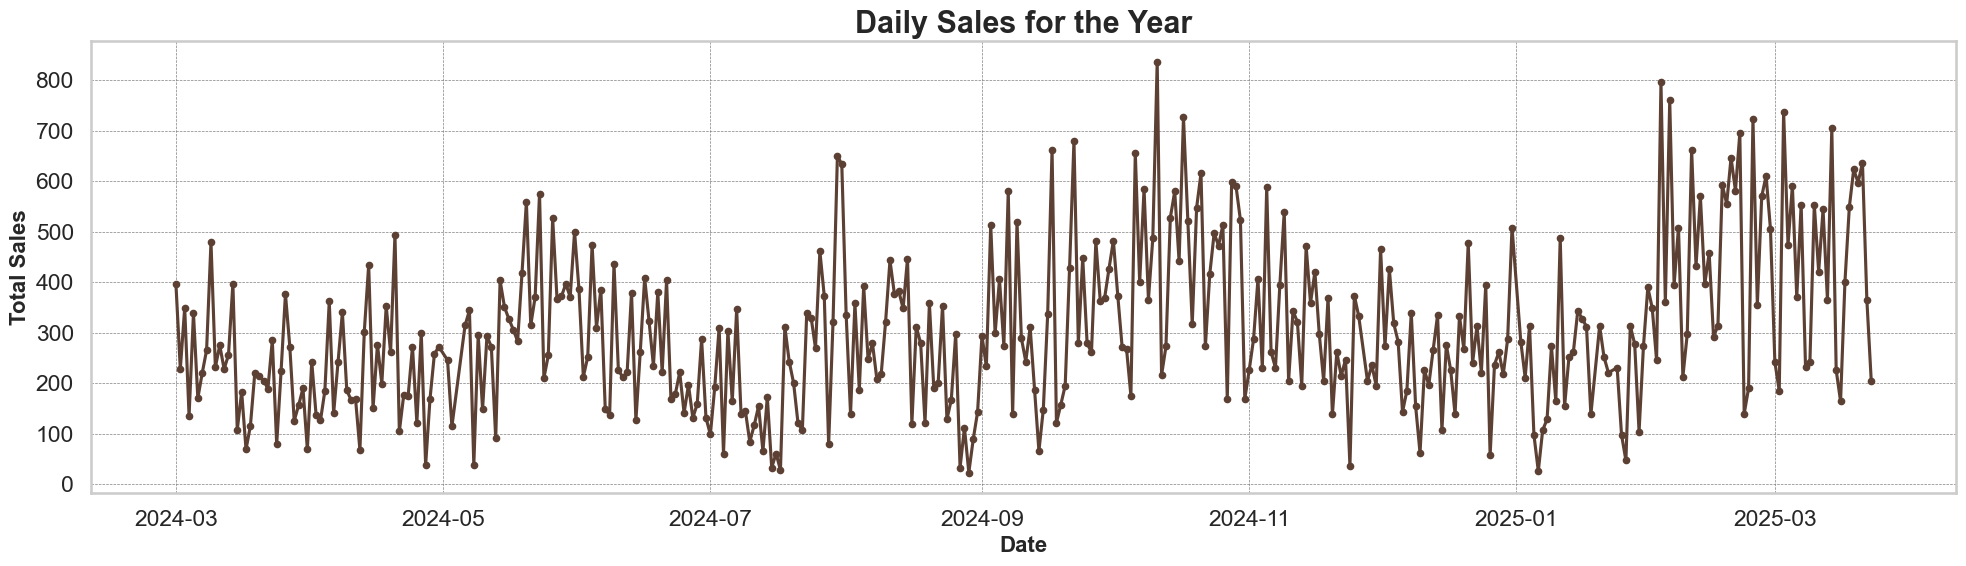

In [14]:
plt.figure(figsize=(20, 6))
plt.plot(daily_sales.index, daily_sales.values, marker='.', linestyle='-', color = "#5C4033")
plt.title('Daily Sales for the Year', fontsize=22, fontweight='bold')
plt.xlabel('Date', fontsize=16, fontweight='bold')
plt.ylabel('Total Sales', fontsize=16, fontweight='bold')
plt.grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()

In [15]:
df['Day of Week'] = df['datetime'].dt.day_name()

daily_hourly_summary = df.groupby(['Day of Week', 'hour'])\
    .agg({'money': ['count', 'sum', 'mean']}).reset_index()
daily_hourly_summary.head()

Day of Week hour money                    
                   count      sum       mean
0      Friday    6     3    87.68  29.226667
1      Friday    7    18   575.08  31.948889
2      Friday    8    49  1480.78  30.220000
3      Friday    9    52  1532.50  29.471154
4      Friday   10    46  1451.84  31.561739

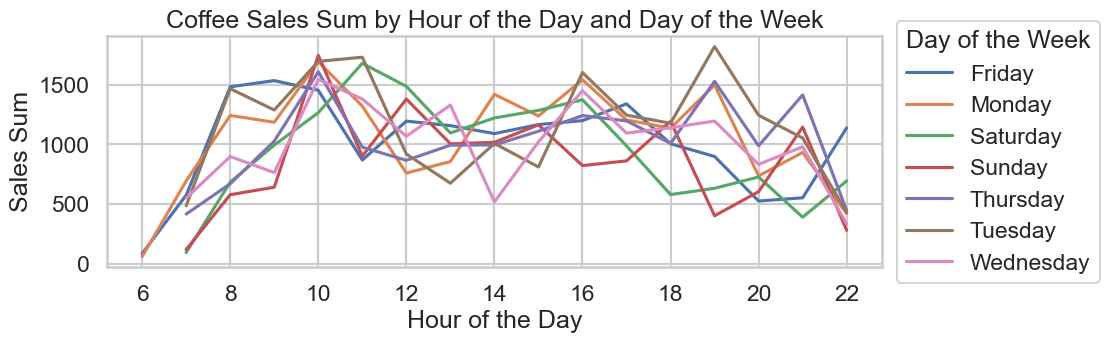

In [16]:
plt.figure(figsize=(10, 3))
sns.lineplot(data=daily_hourly_summary, x='hour', y=('money', 'sum'), hue='Day of Week')
plt.xlabel('Hour of the Day')
plt.ylabel('Sales Sum')
plt.title('Coffee Sales Sum by Hour of the Day and Day of the Week')
plt.legend(title='Day of the Week', bbox_to_anchor=(1.15, 0.5), loc='center');

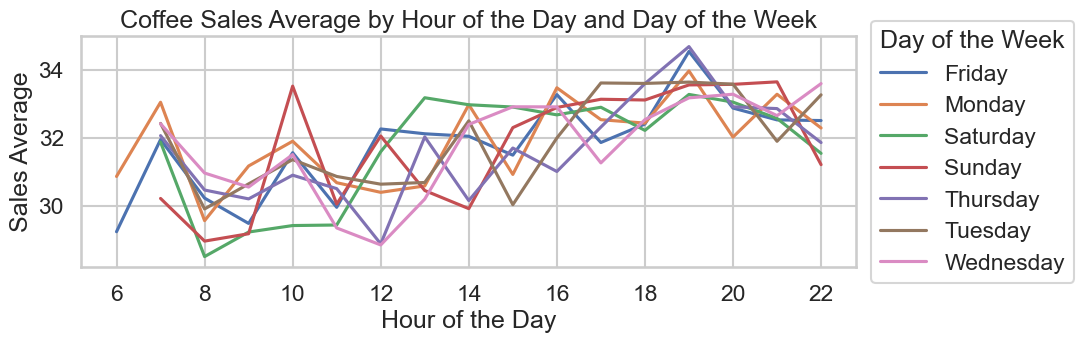

In [17]:
plt.figure(figsize=(10, 3))
sns.lineplot(data=daily_hourly_summary, x='hour', y=('money', 'mean'), hue='Day of Week')
plt.xlabel('Hour of the Day')
plt.ylabel('Sales Average')
plt.title('Coffee Sales Average by Hour of the Day and Day of the Week')
plt.legend(title='Day of the Week', bbox_to_anchor=(1.15, 0.5), loc='center');

In [18]:
df['month'] = df['datetime'].dt.to_period('M')
df['month']

0       2024-03
1       2024-03
2       2024-03
3       2024-03
4       2024-03
         ...   
3631    2025-03
3632    2025-03
3633    2025-03
3634    2025-03
3635    2025-03
Name: month, Length: 3636, dtype: period[M]

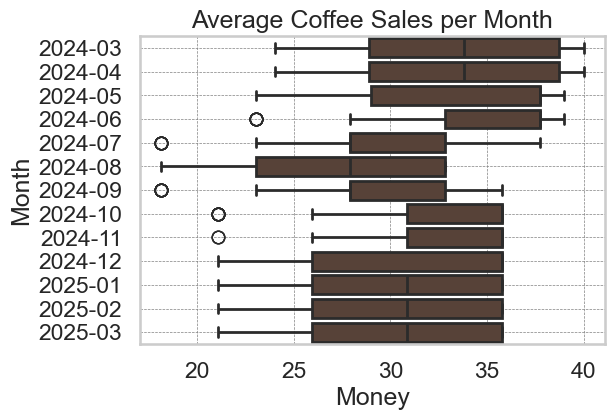

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='money', y='month', data=df, color="#5C4033", linewidth=2)
plt.title('Average Coffee Sales per Month')
plt.xlabel('Money')
plt.ylabel('Month')
plt.grid(True, linestyle="--", linewidth=0.5, color="gray")

plt.show()

In [20]:
monthly_coffee_sales = df.groupby('month')['money'].aggregate('sum')
monthly_coffee_sales = pd.DataFrame(monthly_coffee_sales).reset_index()
monthly_coffee_sales

,month,money
0,2024-03,7050.20
1,2024-04,6720.56
2,2024-05,9063.42
3,2024-06,7758.76
4,2024-07,6915.94
5,2024-08,7613.84
6,2024-09,9988.64
7,2024-10,13891.16
8,2024-11,8590.54
9,2024-12,8237.74


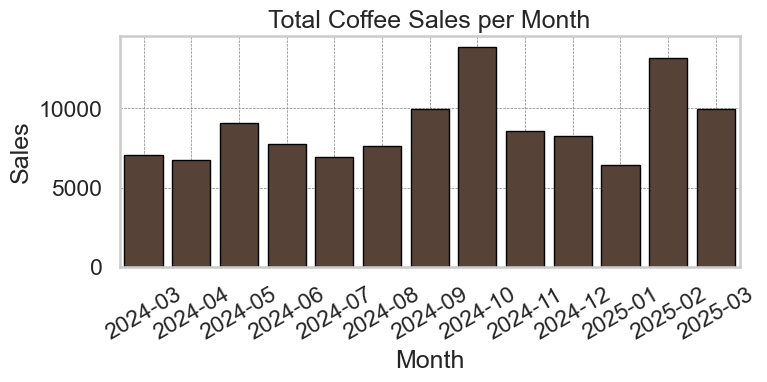

In [21]:
plt.figure(figsize=(8, 3))
sns.barplot(data=monthly_coffee_sales, x='month', y='money', color="#5C4033", edgecolor='black', linewidth=1);
plt.title('Total Coffee Sales per Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=30)
plt.grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.show()

In [22]:
df["day"] = pd.to_datetime(df["date"]).dt.date
df["daily_sales"] = df.groupby(["day", "coffee_name"])["money"].transform("sum")
df["monthly_sales"] = df.groupby(["month", "coffee_name"])["money"].transform("sum")
df["month_str"] = df["month"].dt.strftime('%Y-%m')
df["monthly_sales"]

0       1874.50
1        854.00
2        854.00
3       1044.80
4       1874.50
         ...   
3631    1537.68
3632    1072.80
3633    1072.80
3634    2647.92
3635    2038.32
Name: monthly_sales, Length: 3636, dtype: float64

In [23]:
df["month_str"]

0       2024-03
1       2024-03
2       2024-03
3       2024-03
4       2024-03
         ...   
3631    2025-03
3632    2025-03
3633    2025-03
3634    2025-03
3635    2025-03
Name: month_str, Length: 3636, dtype: object

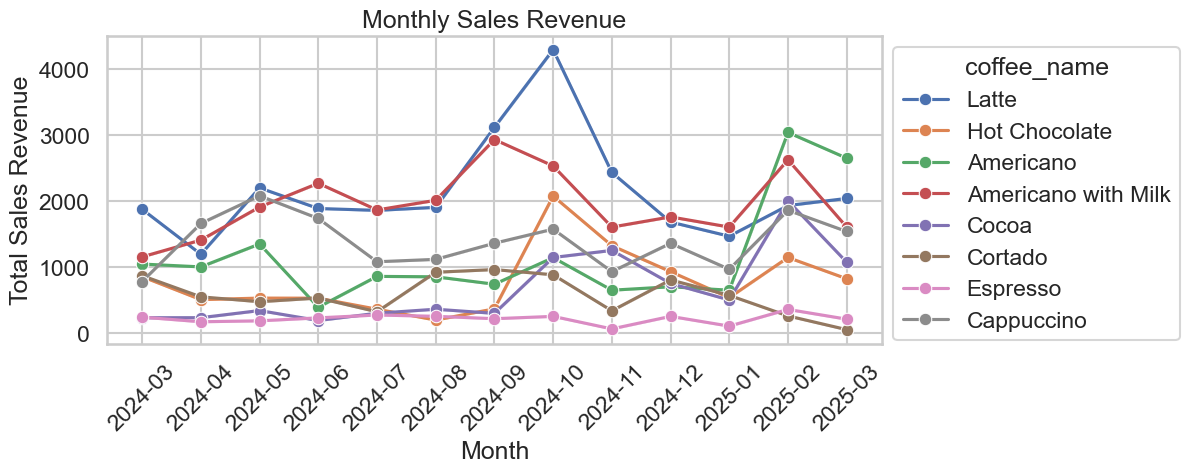

In [24]:
plt.figure(figsize=(10, 4))

sns.set(style="whitegrid")
sns.set_context("talk")

ax = sns.lineplot(data=df, x="month_str", y="monthly_sales", hue="coffee_name", marker="o")

# Grafik ayarları
plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Total Sales Revenue")
plt.xticks(rotation=45)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

In [25]:
coffee_popularity = df['coffee_name'].value_counts()
coffee_popularity

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64

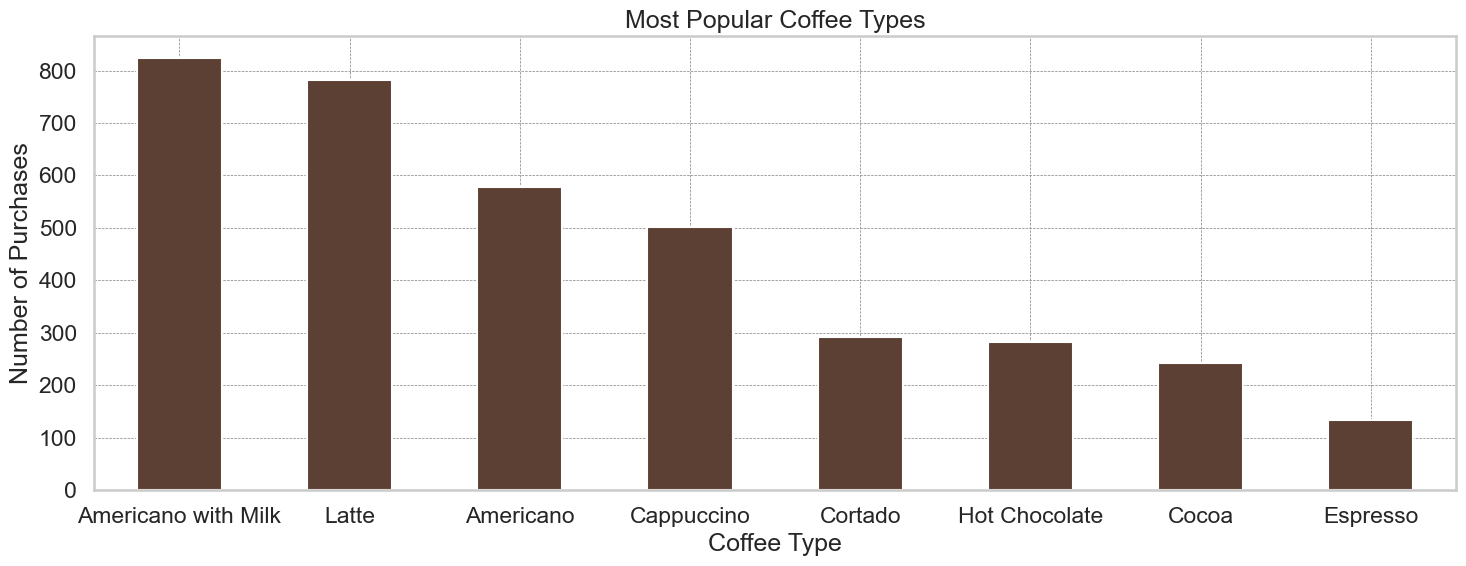

In [26]:
plt.figure(figsize=(15, 6))
coffee_popularity.plot(kind='bar', color="#5C4033")
plt.title('Most Popular Coffee Types')
plt.xlabel('Coffee Type')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=0)
plt.grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()

In [27]:
sales_by_coffee_type = df.groupby('coffee_name')['money'].sum()
sales_by_coffee_type

coffee_name
Americano              15062.26
Americano with Milk    25269.12
Cappuccino             18034.14
Cocoa                   8678.16
Cortado                 7534.86
Espresso                2814.28
Hot Chocolate          10172.46
Latte                  27866.30
Name: money, dtype: float64

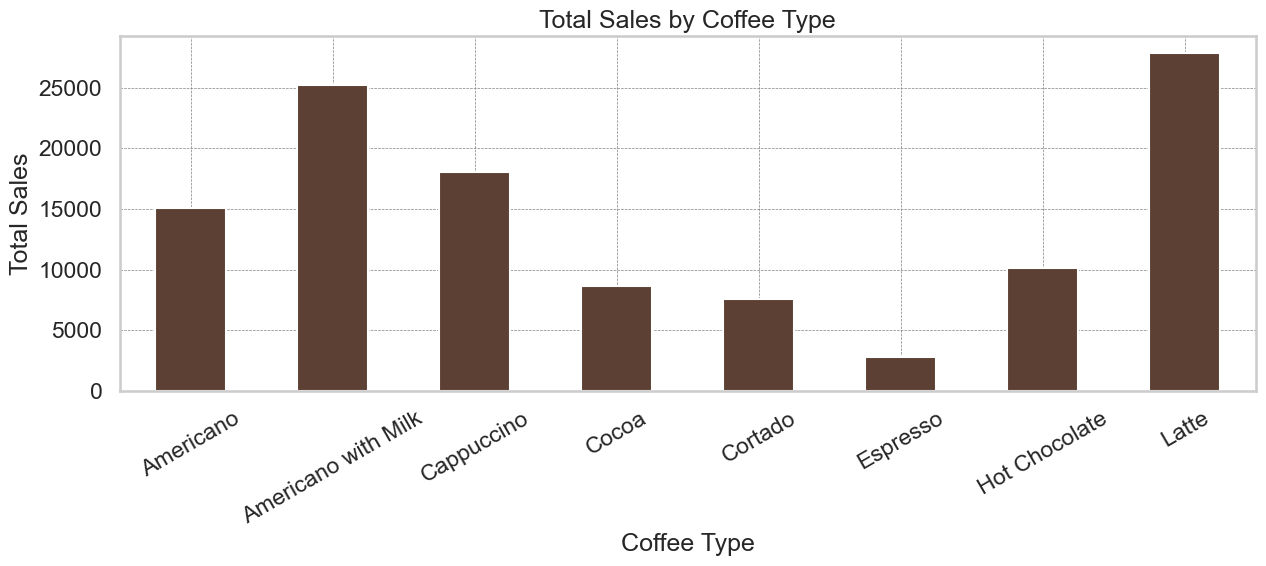

In [28]:
plt.figure(figsize=(13, 6))
sales_by_coffee_type.plot(kind='bar', color="#5C4033")
plt.title('Total Sales by Coffee Type')
plt.xlabel('Coffee Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
plt.grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()